# Análisis y predicción de rotación de personal (Employee Attrition)

**Objetivo:** identificar qué factores predicen que un empleado abandone la empresa, y construir un modelo que lo prediga, para orientar acciones de retención de RRHH.

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) — 1.470 empleados, 35 variables. Datos sintéticos publicados por IBM con fines educativos.

**Autor/a:** *Carlos Rodríguez de la Fuente*

## 1. Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hr.csv')
print('Filas, columnas:', df.shape)
df.head()


Filas, columnas: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Limpieza

Antes de analizar nada, comprobamos si hay columnas sin información (que no varían entre empleados) y valores nulos.


In [2]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'{col}: siempre vale {df[col].unique()[0]} -> se elimina, no aporta información')

print()
print('Valores nulos totales:', df.isnull().sum().sum())


EmployeeCount: siempre vale 1 -> se elimina, no aporta información
Over18: siempre vale Y -> se elimina, no aporta información
StandardHours: siempre vale 80 -> se elimina, no aporta información

Valores nulos totales: 0


In [3]:
# Eliminamos columnas sin información y el identificador de empleado (no predice nada, es un ID)
cols_inutiles = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=cols_inutiles)

# Convertimos la variable objetivo a 0/1 para poder graficarla y modelarla
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

tasa_general = df['Attrition_bin'].mean() * 100
print(f'Tasa de rotación general: {tasa_general:.1f}%')


Tasa de rotación general: 16.1%


## 3. Análisis exploratorio (EDA)

Buscamos qué variables se relacionan más con que un empleado se vaya. La tasa general (16,1%) es nuestra línea base: cualquier grupo muy por encima es un grupo de riesgo.


OverTime
No     10.4
Yes    30.5
Name: Attrition_bin, dtype: float64


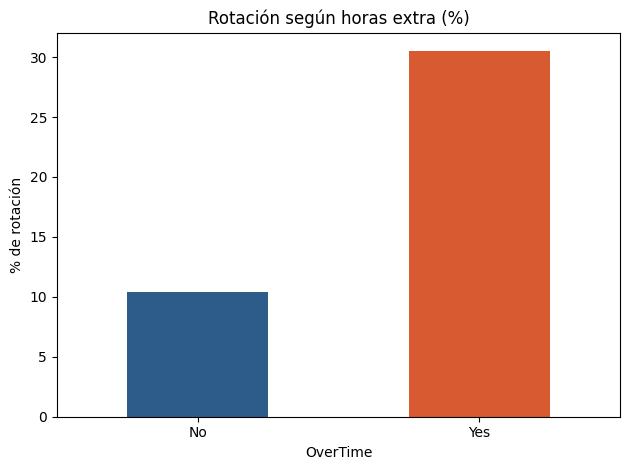

In [4]:
rate_overtime = (df.groupby('OverTime')['Attrition_bin'].mean() * 100).round(1)
print(rate_overtime)

rate_overtime.plot(kind='bar', color=['#2E5C8A', '#D85A30'], title='Rotación según horas extra (%)')
plt.ylabel('% de rotación')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_overtime.png', dpi=120)
plt.show()


**Hallazgo 1:** quien hace horas extra se va 3 veces más (30,5% vs 10,4%). Es el factor individual más fuerte de todo el dataset.

JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition_bin, dtype: float64


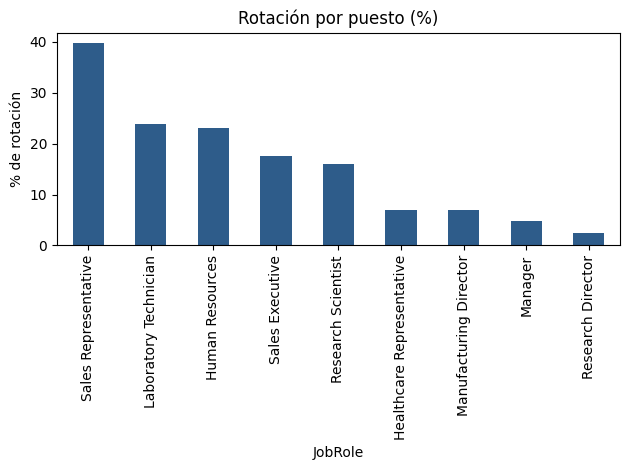

In [5]:
rate_role = (df.groupby('JobRole')['Attrition_bin'].mean() * 100).round(1).sort_values(ascending=False)
print(rate_role)

rate_role.plot(kind='bar', color='#2E5C8A', title='Rotación por puesto (%)')
plt.ylabel('% de rotación')
plt.tight_layout()
plt.savefig('fig_jobrole.png', dpi=120)
plt.show()


**Hallazgo 2:** la rotación se concentra en puestos de entrada (Sales Representative ~40%), frente a puestos directivos (Research Director ~2,5%).

In [6]:
num_df = df.select_dtypes('number')
correlaciones = num_df.corr()['Attrition_bin'].sort_values().drop('Attrition_bin')
print('Factores más relacionados con QUEDARSE (correlación negativa):')
print(correlaciones.head(5))
print()
print('Factores más relacionados con IRSE (correlación positiva):')
print(correlaciones.tail(5))


Factores más relacionados con QUEDARSE (correlación negativa):
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205
Name: Attrition_bin, dtype: float64

Factores más relacionados con IRSE (correlación positiva):
HourlyRate           -0.006846
PerformanceRating     0.002889
MonthlyRate           0.015170
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
Name: Attrition_bin, dtype: float64


**Hallazgo 3:** la antigüedad total, el nivel del puesto y el salario protegen frente a la rotación — a más senioridad, menos abandono.

## 4. Modelo predictivo

Usamos regresión logística: además de predecir, da coeficientes interpretables — ideal para explicar el resultado a perfiles no técnicos de RRHH.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = df.drop(columns=['Attrition', 'Attrition_bin'])
X = pd.get_dummies(X, drop_first=True)
y = df['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# class_weight='balanced': priorizamos detectar más casos reales de fuga (recall),
# aunque baje la precisión -- para RRHH, no detectar a alguien que se va cuesta más
# que revisar de más a alguien que se queda.
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall:', round(recall_score(y_test, y_pred), 3))
print('F1:', round(f1_score(y_test, y_pred), 3))
print()
print('Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.752
Precision: 0.345
Recall: 0.617
F1: 0.443

Matriz de confusión:
[[192  55]
 [ 18  29]]


**Cómo leer estos resultados:**
- *Accuracy 75%* — no basta sola: como solo el 16% se va, un modelo que dijera "nadie se va" ya acertaría el 84% sin aprender nada.
- *Recall 62%* — de cada 10 empleados que realmente se fueron, el modelo detecta a 6. Es la métrica que más importa a RRHH.
- *Precision 34%* — de los que el modelo marca como "en riesgo", 1 de cada 3 se va realmente. Hay falsos positivos, aceptable si el objetivo es no dejar escapar casos reales.


In [8]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

print('Top 5 factores que MÁS reducen el riesgo de irse:')
print(coefs.head(5))
print()
print('Top 5 factores que MÁS aumentan el riesgo de irse:')
print(coefs.tail(5))


Top 5 factores que MÁS reducen el riesgo de irse:
TotalWorkingYears              -0.660270
EducationField_Life Sciences   -0.512319
YearsWithCurrManager           -0.461322
EducationField_Medical         -0.452134
EnvironmentSatisfaction        -0.434370
dtype: float64

Top 5 factores que MÁS aumentan el riesgo de irse:
JobRole_Sales Representative        0.531090
JobLevel                            0.650173
BusinessTravel_Travel_Frequently    0.722538
OverTime_Yes                        0.771095
JobRole_Laboratory Technician       0.810172
dtype: float64


## 5. Conclusiones y recomendaciones

**Hallazgos principales:**
1. Las horas extra triplican el riesgo de fuga (30,5% vs 10,4%) — el factor más determinante.
2. La rotación se concentra en puestos de entrada, especialmente comerciales y técnicos junior.
3. Viajar frecuentemente por trabajo también incrementa el riesgo.
4. La antigüedad protege: los primeros 1-2 años son el momento crítico de retención.

**Recomendaciones para RRHH:**
- Priorizar la reducción de horas extra en roles junior/comerciales antes que subidas salariales generales.
- Reforzar el acompañamiento (mentoring, check-ins) en los primeros años de un empleado.
- Revisar la política de viajes frecuentes en los puestos donde más impacta.

**Modelo predictivo:** detecta correctamente el 62% de los casos reales de fuga, permitiendo anticipar salidas en vez de solo reaccionar a ellas.

---
*Dataset: IBM HR Analytics Employee Attrition & Performance (datos sintéticos, uso educativo).*
